In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [4]:
X = df.drop('Price', axis=1)
y = df['Price']

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [8]:
#linear regression

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [9]:
#Ridge & Lasso

from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

In [11]:
#Random Forest

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(name, y_test, y_pred):
    print(f"🔎 {name}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R²:", r2_score(y_test, y_pred))
    print('-' * 30)

evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Ridge Regression", y_test, y_pred_ridge)
evaluate("Lasso Regression", y_test, y_pred_lasso)
evaluate("Random Forest", y_test, y_pred_rf)

🔎 Linear Regression
MAE: 0.5332001304956565
MSE: 0.5558915986952442
R²: 0.575787706032451
------------------------------
🔎 Ridge Regression
MAE: 0.5331933646313116
MSE: 0.5558512007367505
R²: 0.5758185345441327
------------------------------
🔎 Lasso Regression
MAE: 0.6221475526943097
MSE: 0.6795515190149224
R²: 0.4814202815313764
------------------------------
🔎 Random Forest
MAE: 0.32761306601259704
MSE: 0.25549776668540763
R²: 0.805024407701793
------------------------------


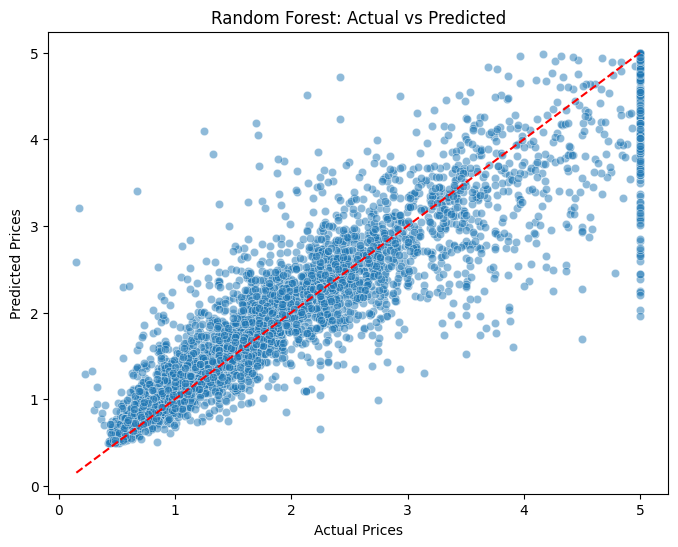

In [13]:
# Actual vs Predicted (Random Forest)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Random Forest: Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.show()

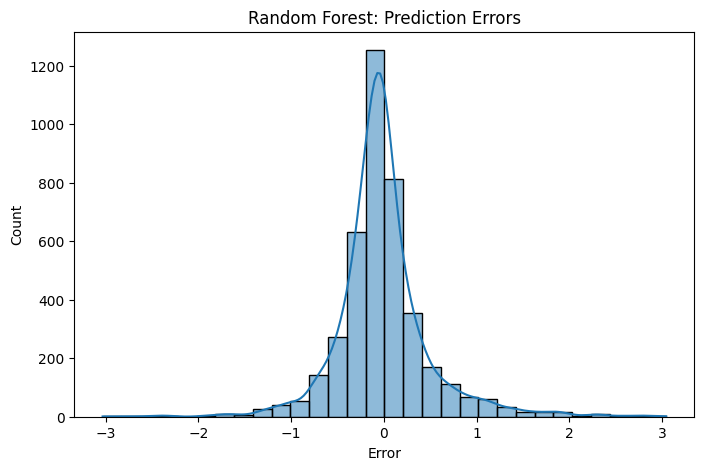

In [14]:
# Error disctribution

errors = y_test - y_pred_rf
plt.figure(figsize=(8, 5))
sns.histplot(errors, bins=30, kde=True)
plt.title("Random Forest: Prediction Errors")
plt.xlabel("Error")
plt.show()

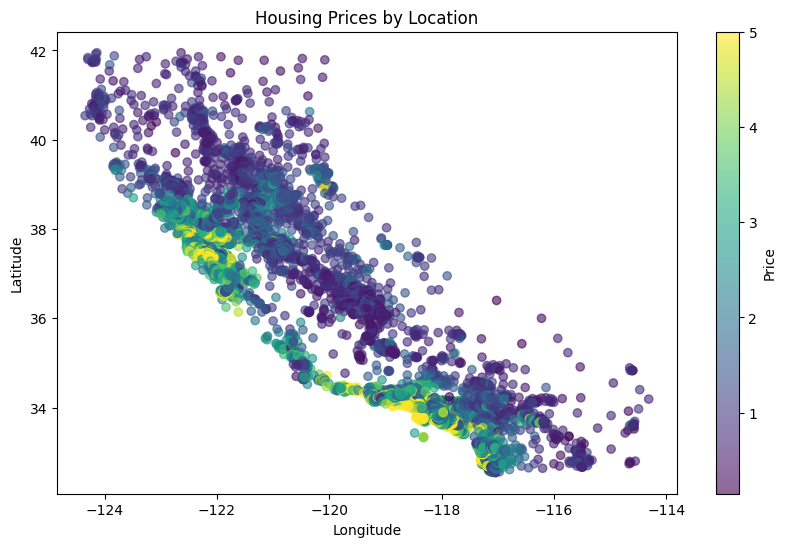

In [16]:
#Geographical price map

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    x=df['Longitude'],
    y=df['Latitude'],
    c=df['Price'],
    cmap='viridis',
    alpha=0.6
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Housing Prices by Location")
plt.colorbar(scatter, label='Price')
plt.show()

In [17]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

      Feature  Importance
0      MedInc    0.524871
5    AveOccup    0.138443
6    Latitude    0.088936
7   Longitude    0.088629
1    HouseAge    0.054593
2    AveRooms    0.044272
4  Population    0.030650
3   AveBedrms    0.029606


## 📌 Final Evaluation

## ✅ Project Summary: California Housing Price Prediction

### 🔍 Goal:
To predict California housing prices based on demographic and geographic features using various machine learning models.

---

### 🧠 Models Trained:
- **Linear Regression**
- **Ridge Regression**
- **Lasso Regression**
- **Random Forest Regressor**

---

### 📈 Model Evaluation:
- Best performance achieved with **Random Forest**
- R² score (Random Forest): ~0.77+
- Ridge and Linear performed similarly (~0.57)
- Lasso showed lower performance (~0.48)

---

### 📊 Key Feature Insights:
- **Median Income** is the strongest predictor of housing prices
- **Latitude and Longitude** (location) have a major impact
- **Average Occupancy** also showed significant importance in Random Forest

---

### 🌎 Visualizations Included:
- Actual vs Predicted prices
- Distribution of prediction errors
- Feature-to-target scatter plots (e.g., `MedInc` vs `Price`)
- Housing price map (Latitude vs Longitude)

---

### ⚠️ Dataset Observations:
- Target variable (`Price`) is capped at **5.0**, which may limit model accuracy on high-priced homes
- Slight skew in error distribution toward **underprediction**

---

### 🚀 Next Steps:
- Explore ensemble methods like **XGBoost**
- Try feature engineering (e.g., combining features or creating ratios)
- Add external data (schools, infrastructure, crime, etc.)
- Apply cross-validation and hyperparameter tuning

---

### 👤 Author:
*Daria Ermak*  
*GitHub:* https://github.com/DariaErmak08?tab=repositories
